In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as stats
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from sklearn.preprocessing import PowerTransformer
import warnings
warnings.filterwarnings('ignore')

In [ ]:
df = pd.read_csv('/content/concrete_data.csv')
df.head(3)

,Cement,Blast Furnace Slag,Fly Ash,Water,Superplasticizer,Coarse Aggregate,Fine Aggregate,Age,Strength
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.99
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.89
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270,40.27


In [ ]:
df.shape

(1030, 9)

In [ ]:
df.isnull().sum()

,0
Cement,0
Blast Furnace Slag,0
Fly Ash,0
Water,0
Superplasticizer,0
Coarse Aggregate,0
Fine Aggregate,0
Age,0
Strength,0


In [ ]:
df.describe()

,Cement,Blast Furnace Slag,Fly Ash,Water,Superplasticizer,Coarse Aggregate,Fine Aggregate,Age,Strength
count,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000
mean,281.167864,73.895825,54.188350,181.567282,6.204660,972.918932,773.580485,45.662136,35.817961
std,104.506364,86.279342,63.997004,21.354219,5.973841,77.753954,80.175980,63.169912,16.705742
min,102.000000,0.000000,0.000000,121.800000,0.000000,801.000000,594.000000,1.000000,2.330000
25%,192.375000,0.000000,0.000000,164.900000,0.000000,932.000000,730.950000,7.000000,23.710000
50%,272.900000,22.000000,0.000000,185.000000,6.400000,968.000000,779.500000,28.000000,34.445000
75%,350.000000,142.950000,118.300000,192.000000,10.200000,1029.400000,824.000000,56.000000,46.135000
max,540.000000,359.400000,200.100000,247.000000,32.200000,1145.000000,992.600000,365.000000,82.600000


**Here , We can see "Blast Furnace Slag" and 'Superplasticizer'and 'Fly Ash' these columns has a missing values of 0 which is creating problem for us right now**

In [ ]:
X = df.drop(columns='Strength')
y = df['Strength']
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.fit_transform(X_test)

In [ ]:
lr = LinearRegression()
lr.fit(X_train_scaled,y_train)


LinearRegression()

In [ ]:
y_pred = lr.predict(X_test_scaled)
r2_score(y_test,y_pred)


0.6189650039386507

In [ ]:
#Cross checking with cross val score
np.mean(cross_val_score(lr,X,y,scoring='r2'))

np.float64(0.46099404916628606)

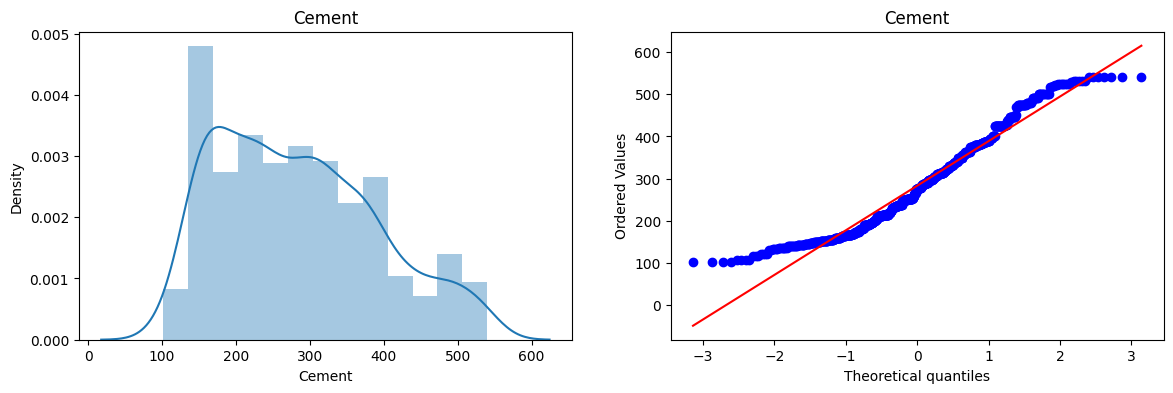

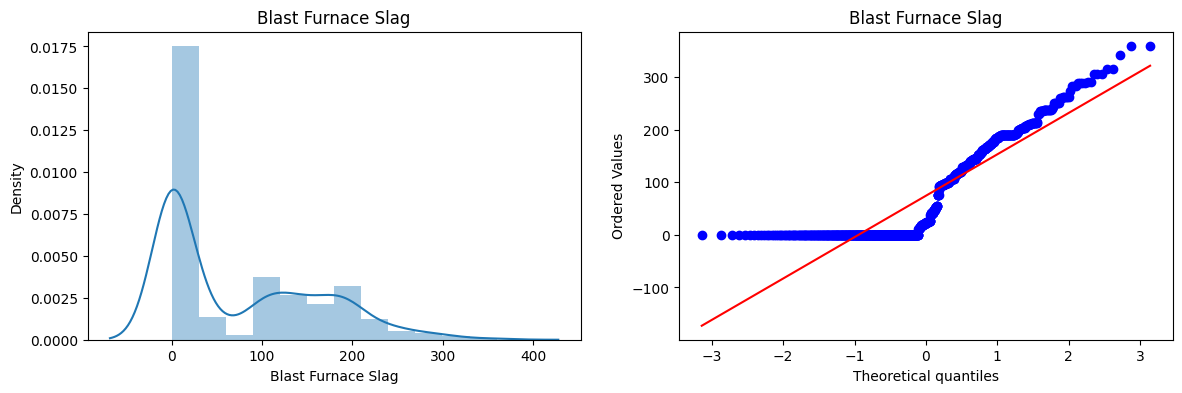

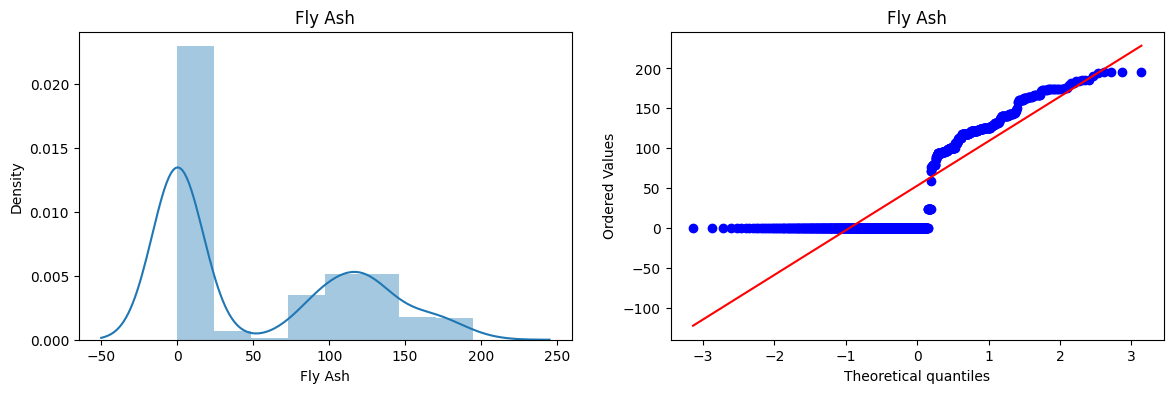

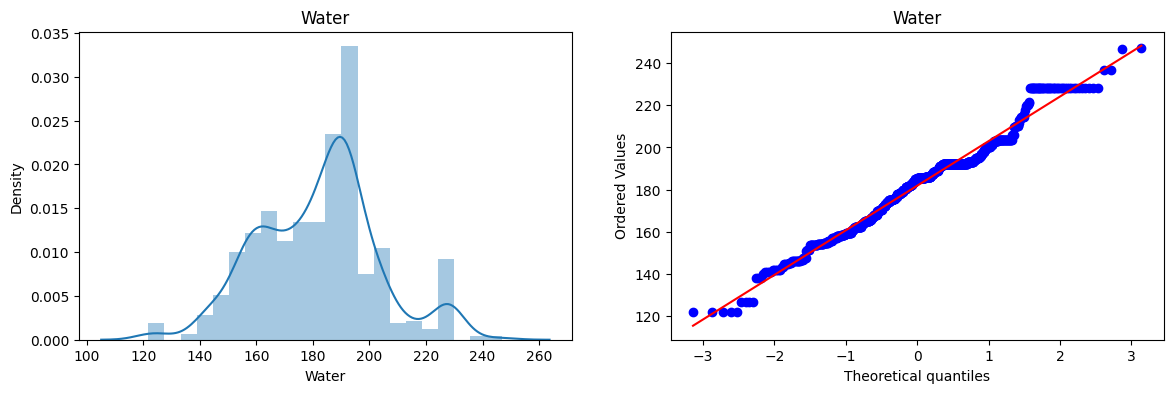

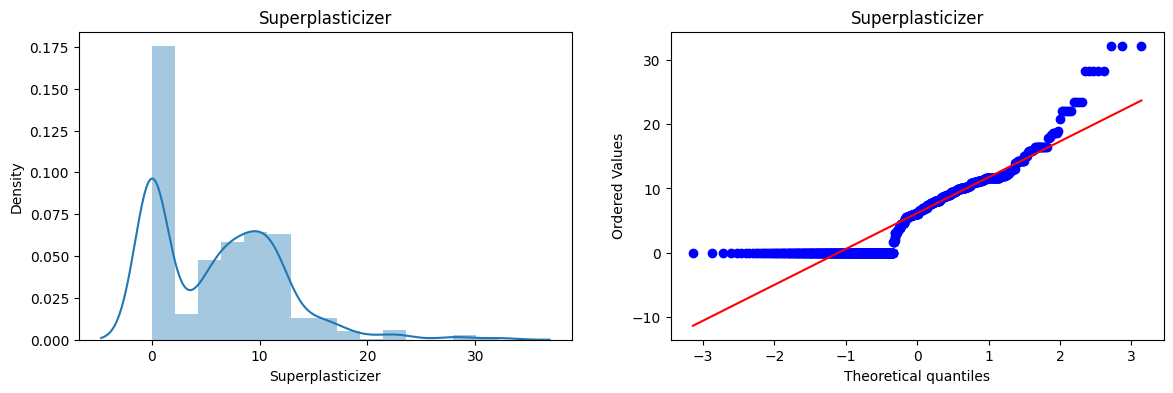

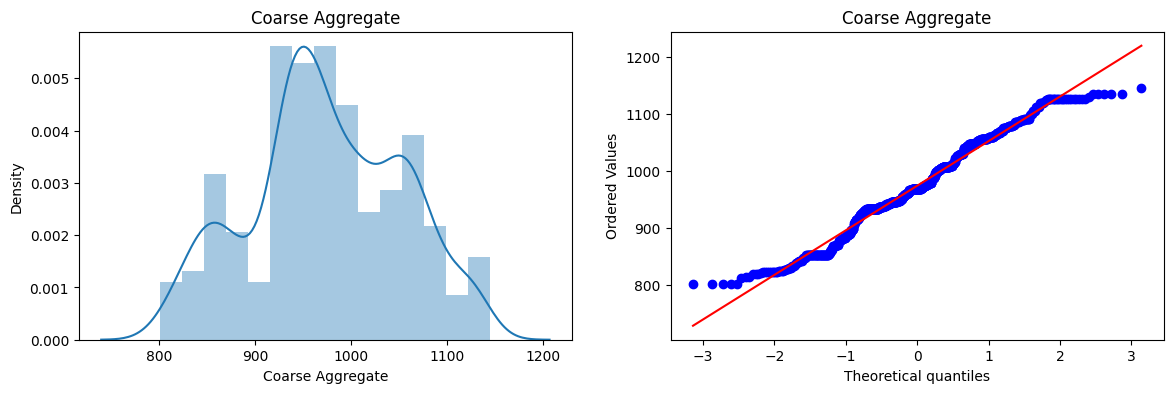

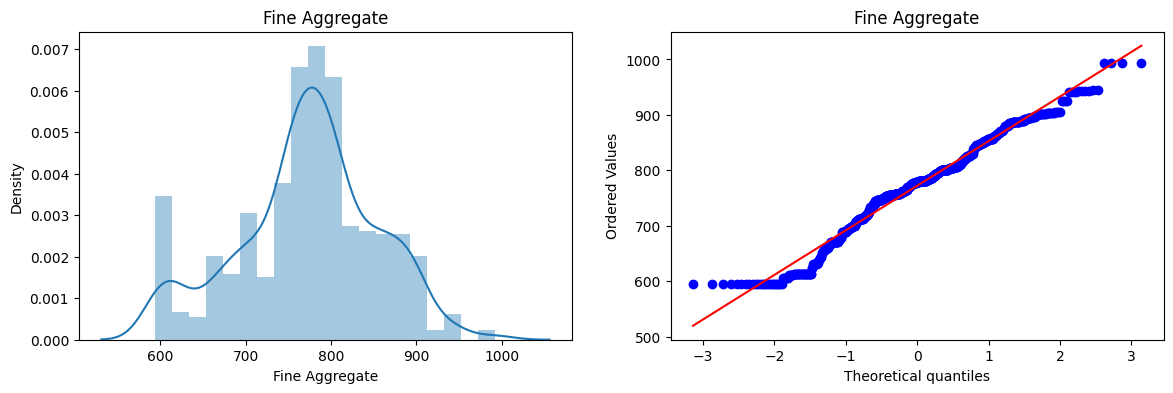

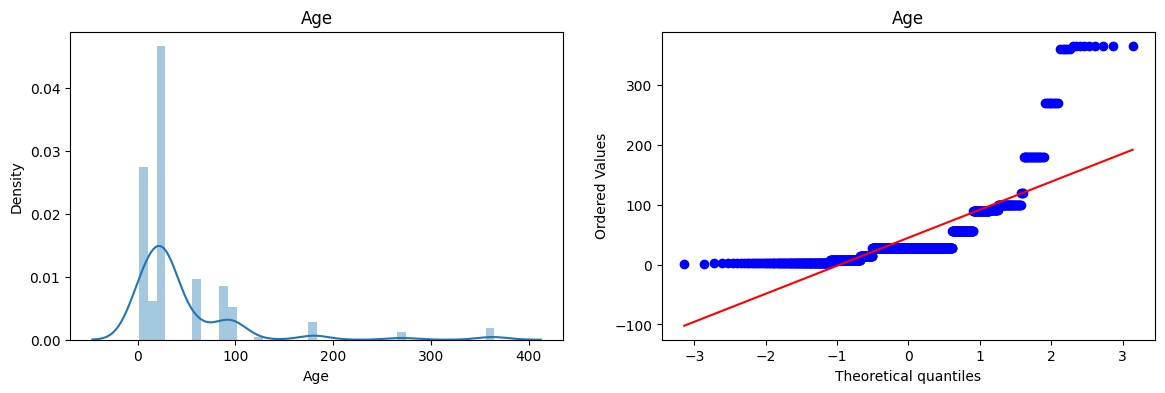

In [ ]:
for col in X_train.columns:
  plt.figure(figsize=(14,4))
  plt.subplot(121)
  sns.distplot(X_train[col])
  plt.title(col)

  plt.subplot(122)
  stats.probplot(X_train[col],dist='norm',plot=plt)
  plt.title(col)
  plt.show()

In [ ]:
pt = PowerTransformer(method='box-cox',standardize=True)
X_train_transformed = pt.fit_transform(X_train+0.00001)
X_test_transformed = pt.transform(X_test+0.00001)

pd.DataFrame({'cols':X_train.columns,'box_cox_lambdas':pt.lambdas_})

,cols,box_cox_lambdas
0,Cement,0.177025
1,Blast Furnace Slag,0.027842
2,Fly Ash,-0.044554
3,Water,0.772682
4,Superplasticizer,0.113892
5,Coarse Aggregate,1.129813
6,Fine Aggregate,1.782018
7,Age,0.066630


In [ ]:
lr = LinearRegression()
lr.fit(X_train_transformed,y_train)

y_pred2 = lr.predict(X_test_transformed)
r2_score(y_test,y_pred2)

0.8054599368449091

In [ ]:
np.mean(cross_val_score(lr,X_train_transformed,y_train,scoring='r2'))

np.float64(0.7925098471046027)

In [ ]:
X_train_transformed

array([[-1.27975148,  0.96070173,  1.12820284, ..., -0.26250009,
        -0.67756847,  0.1060097 ],
       [ 1.24470595,  0.67299782,  1.13907395, ..., -1.91272789,
        -0.3140622 ,  0.1060097 ],
       [ 0.07984237, -1.08475523,  1.13203814, ...,  1.01840672,
         0.02595744, -1.67596992],
       ...,
       [-0.84451727, -1.08475523,  1.13463171, ...,  1.34536665,
         0.29715694,  1.24673347],
       [ 1.5656235 ,  0.925921  , -0.88716424, ..., -1.53725479,
         0.0762111 ,  0.1060097 ],
       [ 0.42655632, -1.08475523,  1.12599069, ..., -0.62083415,
         0.0951082 ,  0.1060097 ]])

In [ ]:
X_train_transformed = pd.DataFrame(X_train_transformed,
                                   columns=['Cement',
                                            'Blast Furnace Slag',
                                            'Fly Ash',
                                            'Water','Superplasticizer','Coarse Aggregate','Fine Aggregate','Age'])


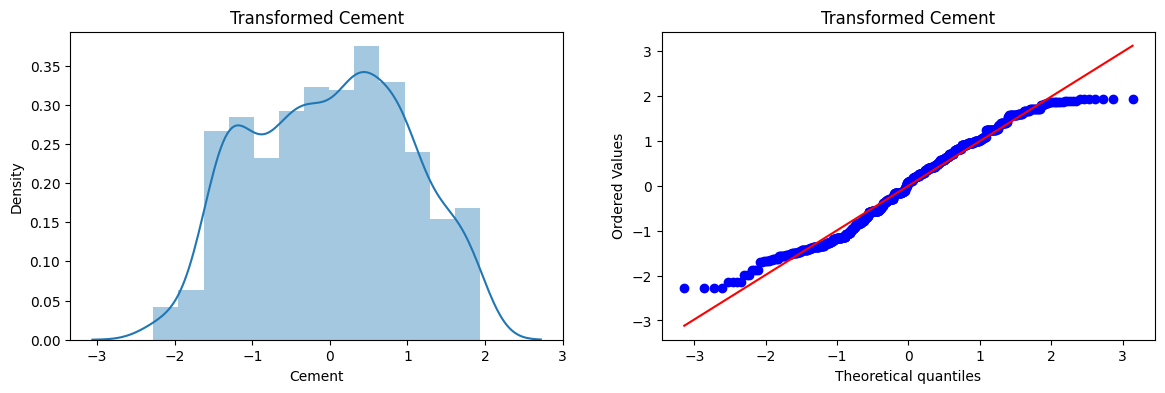

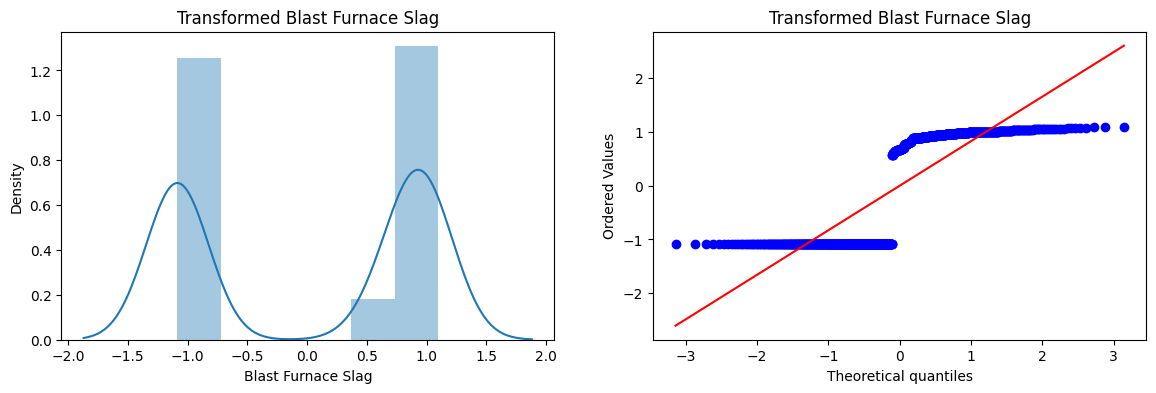

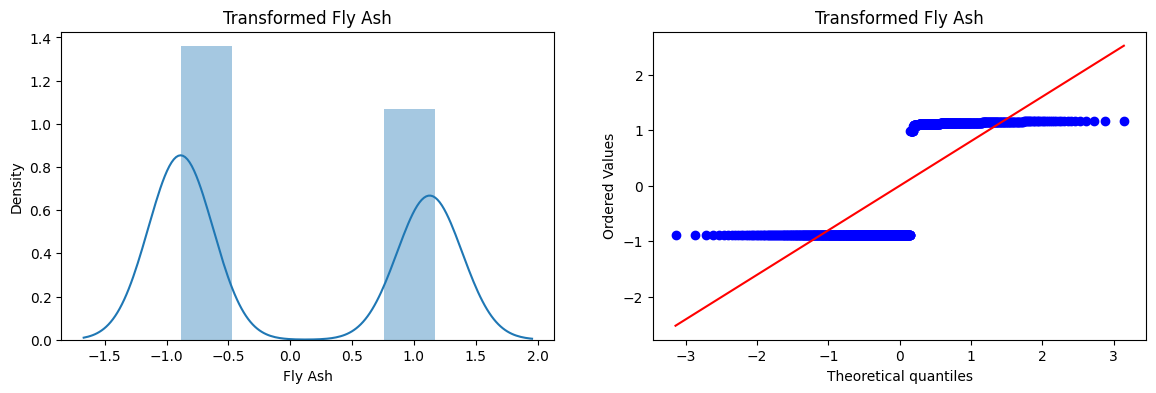

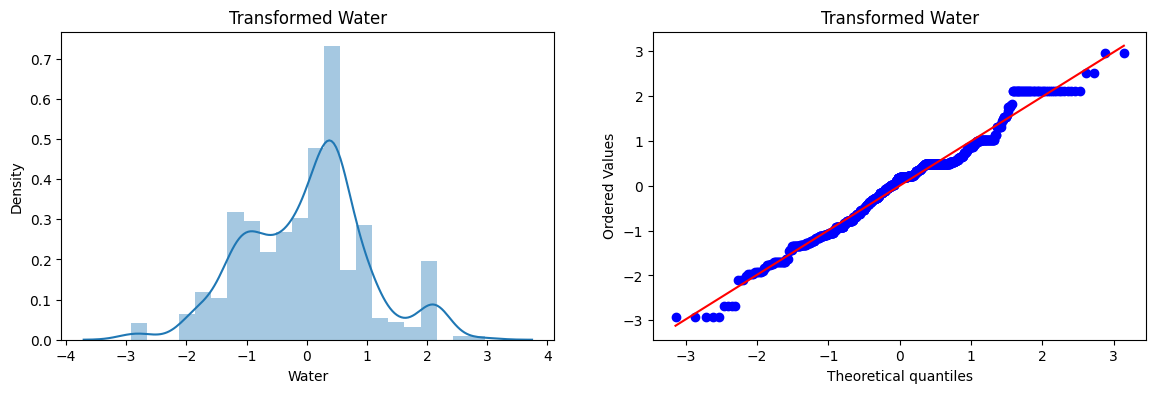

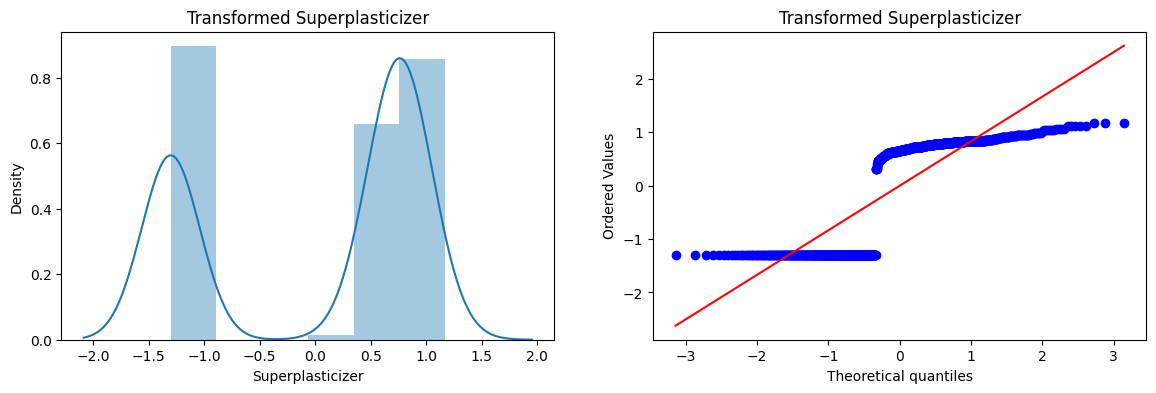

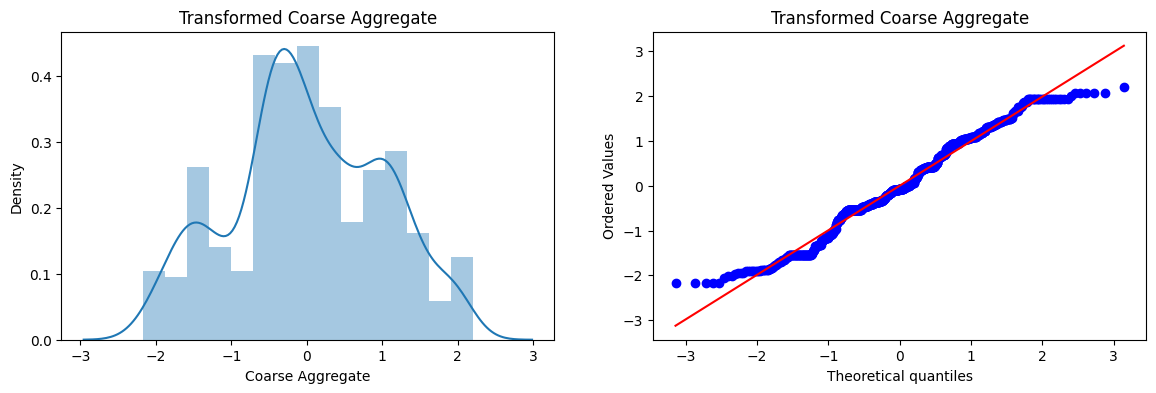

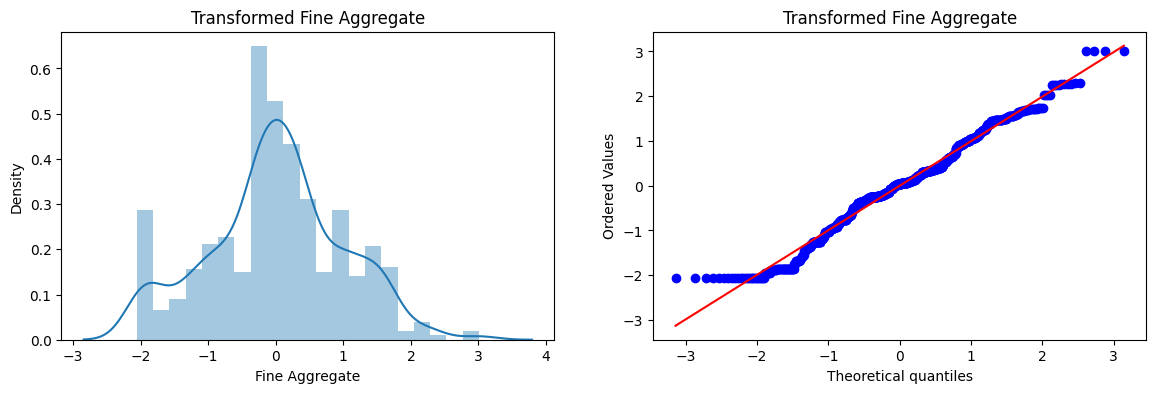

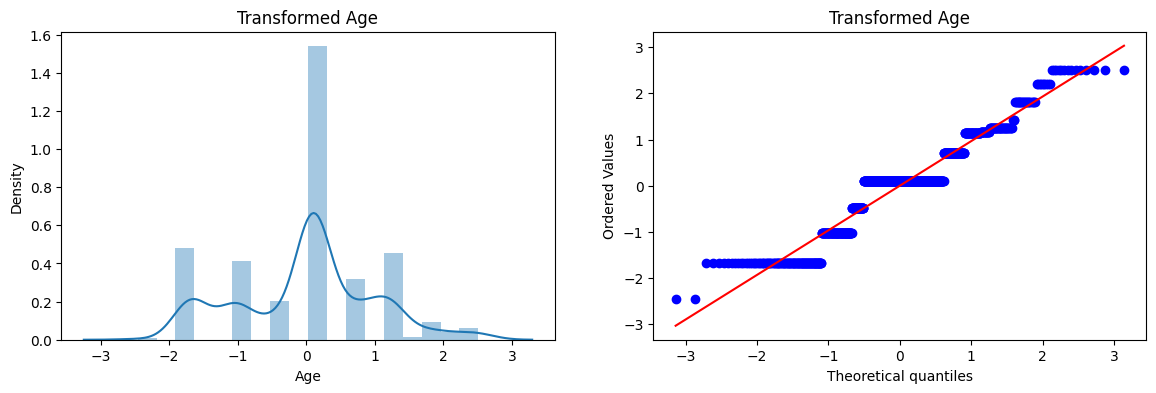

In [ ]:
for col in X_train_transformed.columns:
  plt.figure(figsize=(14,4))
  plt.subplot(121)
  sns.distplot(X_train_transformed[col])
  plt.title(f"Transformed {col}")

  plt.subplot(122)
  stats.probplot(X_train_transformed[col],dist='norm',plot=plt)
  plt.title(f'Transformed {col}')

# **Yeo - Johnson Transform**

In [ ]:
pt2 = PowerTransformer()
X_train_transformed2 = pt2.fit_transform(X_train)
X_test_transformed2 = pt2.transform(X_test)

lr = LinearRegression()
lr.fit(X_train_transformed2,y_train)

y_pred3 = lr.predict(X_test_transformed2)
print(r2_score(y_test,y_pred3))

pd.DataFrame({'cols':X_train.columns,'Yeo - Johnson_lambdas':pt2.lambdas_})

0.8161906512004999


,cols,Yeo - Johnson_lambdas
0,Cement,0.174348
1,Blast Furnace Slag,0.015715
2,Fly Ash,-0.161447
3,Water,0.771307
4,Superplasticizer,0.253935
5,Coarse Aggregate,1.130050
6,Fine Aggregate,1.783100
7,Age,0.019885


In [ ]:
np.mean(cross_val_score(lr,X_train_transformed2,y_train,scoring='r2'))

np.float64(0.7941782180737023)